# Statistical Analysis

## Install Libraries

In [ ]:
pip install pandas numpy statistics matplotlib kagglehub seaborn

## Import libraries

In [ ]:
import os
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import statistics as stats
import matplotlib.pyplot as plt

## [PARTE MARIAH]

In [ ]:
# Download dataset from Kaggle
print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("salomaoalves/enem-score")
print("Path to dataset files:", path)

pd.set_option('display.precision', 3)

files = os.listdir(path)
print("Files in directory:", files)

csv_file = None
for file in files:
    if file.endswith('.csv'):
        csv_file = os.path.join(path, file)
        break

if csv_file:
    print(f"Reading CSV file: {csv_file}")
    df = pd.read_csv(csv_file, sep=';')
else:
    print("No CSV file found in the directory")
    exit()

# Define score columns
scores = ["NU_NOTA_CH", "NU_NOTA_CN", "NU_NOTA_LC", "NU_NOTA_MT"]

print("\n=== Score Statistics ===")

# Mean, median and mode using complete vectors
scores_mean = df[scores].mean()
scores_median = df[scores].median()
scores_mode = df[scores].mode().iloc[0]  # returns one row with the mode of each column

print("Mean scores:\n", scores_mean)
print("\nMedian scores:\n", scores_median)
print("\nMode scores:\n", scores_mode)

# Overall average of participants
df["OVERALL_AVERAGE"] = df[scores].mean(axis=1)

print(f"\nOverall participant average: {df['OVERALL_AVERAGE'].mean():.2f}")

# Complete distribution verification
print("\n=== Score Frequencies ===")
for col in scores:
    print(f"\nFrequencies of {col}:")
    print(df[col].value_counts())

print("\n=== Age Distribution ===")
print("Mean:", df["NU_IDADE"].mean().round(2))
print("Median:", df["NU_IDADE"].median().round(2))
print("Mode:", df["NU_IDADE"].mode().iloc[0])

print("\n=== Number of participants by State ===")
print(df["SG_UF_PROVA"].value_counts())

print("\n=== Percentage of participants by State (%) ===")
print((df["SG_UF_PROVA"].value_counts(normalize=True) * 100).round(2))

# === CHART ===

state_averages = df.groupby("SG_UF_PROVA")["OVERALL_AVERAGE"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
plt.bar(state_averages.index, state_averages.values)

plt.title("States with highest overall average in ENEM 2015")
plt.xlabel("State")
plt.ylabel("Overall Average")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('average_by_state.png')
plt.show()

## Correlation Analysis

Dataset loaded successfully.
Calculating 'OVERALL_AVERAGE'...

Calculating correlation matrix...

=== Correlation Matrix ===
                 NU_NOTA_CH  NU_NOTA_CN  NU_NOTA_LC  NU_NOTA_MT  \
NU_NOTA_CH            1.000       0.559       0.678       0.508   
NU_NOTA_CN            0.559       1.000       0.551       0.587   
NU_NOTA_LC            0.678       0.551       1.000       0.526   
NU_NOTA_MT            0.508       0.587       0.526       1.000   
OVERALL_AVERAGE       0.823       0.810       0.816       0.840   

                 OVERALL_AVERAGE  
NU_NOTA_CH                 0.823  
NU_NOTA_CN                 0.810  
NU_NOTA_LC                 0.816  
NU_NOTA_MT                 0.840  
OVERALL_AVERAGE            1.000  

Generating heatmap...

Heatmap saved successfully as 'correlation_heatmap.png'


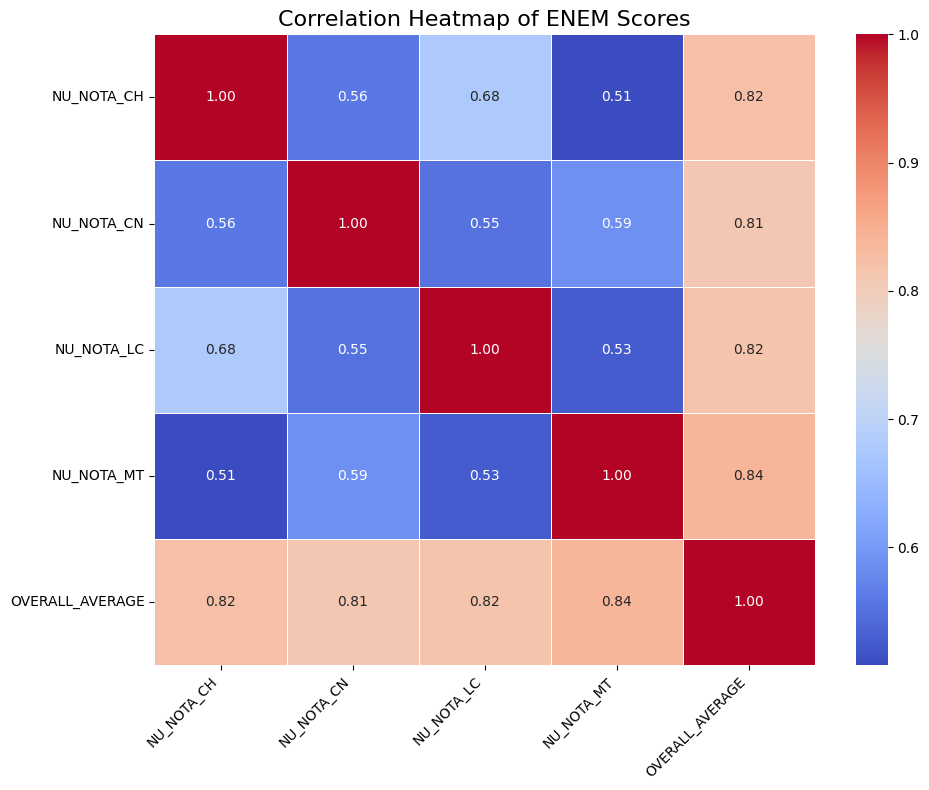

In [7]:
try:
    for file in os.listdir(path):
        if file.endswith('.csv'):
            csv_file = os.path.join(path, file)
            break

    if not csv_file:
        print("Error: CSV file not found in dataset.")
    else:
        df = pd.read_csv(csv_file, sep=';')
        print("Dataset loaded successfully.")

        # --- Correlation Analysis ---
        score_components = ["NU_NOTA_CH", "NU_NOTA_CN", "NU_NOTA_LC", "NU_NOTA_MT"]
        
        # Calculate OVERALL_AVERAGE if it doesn't exist
        if 'OVERALL_AVERAGE' not in df.columns:
            print("Calculating 'OVERALL_AVERAGE'...")
            df['OVERALL_AVERAGE'] = df[score_components].mean(axis=1)

        score_columns = score_components + ['OVERALL_AVERAGE']
        scores_df = df[score_columns]

        print("\nCalculating correlation matrix...")
        correlation_matrix = scores_df.corr()

        print("\n=== Correlation Matrix ===")
        print(correlation_matrix)

        # --- Visualization ---
        print("\nGenerating heatmap...")
        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
        plt.title('Correlation Heatmap of ENEM Scores', fontsize=16)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        
        # Save the figure and display it
        output_filename = 'correlation_heatmap.png'
        plt.savefig(output_filename)
        print(f"\nHeatmap saved successfully as '{output_filename}'")
        plt.show()

except Exception as e:
    print(f"An error occurred: {e}")